<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F03_spark_serverless_and_connect.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 03 · Distributed Apache Spark: Serverless Batch, Cluster & Interactive Spark Connect

`scale-forecasting` supports three Apache Spark execution modes (`engines/spark_explode.py` & `engines/spark_io.py`), all executing the **identical Arrow-backed `groupBy(bucket).applyInPandas` worker UDF**:
1. **Dataproc Serverless Batch (`compute.spark_mode = 'serverless'`):** Zero-ops autoscaling Spark batch with dynamic allocation.
2. **Dataproc Standard Cluster (`compute.spark_mode = 'cluster'`):** Ephemeral or pre-existing GCE-backed Dataproc cluster.
3. **Interactive Spark Connect (`Forecaster.run(spark=spark)`):** Drives a remote Dataproc Spark cluster interactively from this notebook kernel over gRPC (`DataprocSparkSession` on Dataproc runtime `2.3`).
4. **Direct Engine Embedding (`spark_io.run_group` & `make_group_runner`):** Embed the pure Spark grouped-UDF runner directly inside an existing PySpark pipeline.

```mermaid
flowchart LR
    subgraph Modes["compute.spark_mode & Interactive Connect"]
        M1["serverless<br/>Dataproc Serverless Batch"]
        M2["cluster<br/>Dataproc GCE Cluster"]
        M3["spark=DataprocSparkSession<br/>Interactive Spark Connect (Runtime 2.3)"]
    end
    subgraph UDF["engines/spark_io.py (Zero-Copy Arrow Fan-Out)"]
        READ["BigQuery Storage Read API<br/>Direct Arrow Stream"] --> CROSS["Cross-Join Series x Models<br/>Hash Bucket Partitioning"]
        CROSS --> APPLY["groupBy(bucket).applyInPandas<br/>spark_io.run_group()"]
    end
    M1 & M2 & M3 --> READ
    APPLY --> WRITE["BigQuery Storage Write API<br/>Streaming Executor Flush"]
```

## Act 1 · Cloud Bootstrap & Deployment Resolution

On a managed cloud notebook (**Colab Enterprise**, **Vertex AI Workbench**) the bootstrap cell below clones or updates the repository and installs the locked dependency set (`uv.lock`) into an isolated `.colab-deps` prefix so `import scale_forecasting` resolves against the exact package versions every cloud worker uses. **In a local clone with `.venv`, this cell is a fast no-op.**

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")
EXTRAS = ['spark']

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags, "-o", reqs],
        cwd=REPO_DIR,
        check=True,
    )
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))
    print("installed scale_forecasting from", REPO_DIR)
else:
    print("scale_forecasting already importable — skipping bootstrap")

scale_forecasting already importable — skipping bootstrap


### Resolve the Live GCP Deployment (`Settings.resolve()`)

`Settings.resolve()` reads the `SF_*` environment variables (`SF_PROJECT_ID`, `SF_REGION`, `SF_DATASET_ID`, `SF_WAREHOUSE_URI`, `SF_CONNECTION`, `SF_COMPUTE_SA`) pre-populated by Terraform in the `sf-main` runtime template (or your local shell).

In [2]:
from google.cloud import bigquery
from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print(f"Deployment: {DATASET} | Region: {settings.region} | Bucket: {settings.warehouse_uri}")

Deployment: statmike-scale-forecasting.scale_forecasting | Region: us-central1 | Bucket: gs://statmike-scale-forecasting-warehouse/warehouse


## Act 2 · Configure & Explain the Spark Execution Plan (`forecaster.explain()`)

We configure a hybrid Spark + BigQuery ML run (`theta` and `holtwinters` on Spark CPU $\parallel$ `arima_plus` and `timesfm` in BigQuery SQL) with in-run ensembling (`mean`, `median`, `inverse_error`).

In [3]:
import time
from scale_forecasting import Forecaster, RunConfig

# === Parameters — edit me ===============================================
RUN_NAME = f"nb03 spark serverless {int(time.time())}"
SOURCE_TABLE = "source_series_iceberg"
MODELS = ["theta", "holtwinters", "arima_plus", "timesfm"]
HORIZON = 28
SERIES_LIMIT = 12
N_FOLDS = 2
ENSEMBLE_STRATEGIES = ["mean", "median", "inverse_error"]
# ========================================================================

cfg = RunConfig(
    run_name=RUN_NAME,
    python_runtime="spark",
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=MODELS,
    features={"holidays": ["US"]},
    backtest={"enabled": True, "n_folds": N_FOLDS, "horizon": HORIZON, "step": HORIZON},
    ensemble={"enabled": True, "strategies": ENSEMBLE_STRATEGIES},
)

forecaster = Forecaster(cfg, settings=settings)
print("run_id:", forecaster.run_id)
display(forecaster.explain())

run_id: nb03-spark-serverless-1791144910-9353ee60d3c4


,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb03-spark-serverless-1791144910-9353ee60d3c4,statistical,sf-nb03-spark-serverless-1791144910-9353ee60d3...,spark,None,NaN,cpu,None,"theta, holtwinters","theta:local, holtwinters:local",12,2,24,none,
1,nb03-spark-serverless-1791144910-9353ee60d3c4,native,sf-nb03-spark-serverless-1791144910-9353ee60d3...,bigquery,sql,1.0,sql,None,"arima_plus, timesfm","arima_plus:local, timesfm:local",12,2,24,none,
2,nb03-spark-serverless-1791144910-9353ee60d3c4,ensemble,sf-nb03-spark-serverless-1791144910-9353ee60d3...,bigquery,sql,1.0,sql,None,"ensemble_mean, ensemble_median, ensemble_inver...",barrier,12,2,36,none,sf-nb03-spark-serverless-1791144910-9353ee60d3...


## Act 3 · Launch & Monitor Live (`forecaster.run_live()`)

`forecaster.run_live()` dispatches the Dataproc Serverless batch for `statistical` in parallel with the BigQuery native SQL queries for `native`, monitors real-time cell completion, and runs the downstream ensembler.

Run nb03-spark-serverless-1791144910-9353ee60d3c4 completed: status=COMPLETED, wall_clock=1622.2s


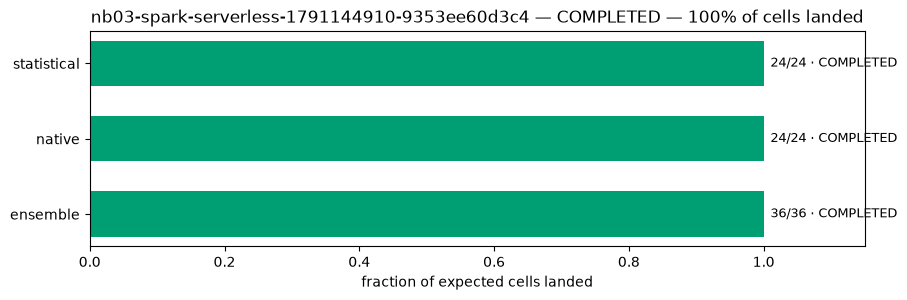

In [4]:
result = forecaster.run_live(poll_s=15.0, probe=True)
print(f"Run {result.run_id} completed: status={result.status}, wall_clock={result.runtime_seconds:.1f}s")

## Act 4 · Review Unified Leaderboard, Forecast Fan Charts & Execution Trace

Notice how `compute_engine` in `forecaster.leaderboard_df()` cleanly distinguishes `spark`, `bigquery`, and `ensemble` rows ranked on the identical `mean_wape` metric.

,rank,model_type,family,is_ensemble,ensemble_id,compute_engine,n_series,decision_metric,score,pooled_wape,...,mean_mae,mean_rmse,mean_coverage,mean_interval_score,mean_fit_seconds,median_fit_seconds,no_artifact_rate,n_predictions,lift_vs_best_base,lift_pct
0,1,arima_plus,native,False,None,bigquery,12,wape,0.407766,0.122417,...,11.823062,15.666697,0.601190,61.122848,NaN,NaN,1.0,336,NaN,NaN
1,2,timesfm,native,False,None,bigquery,12,wape,0.416052,0.120099,...,12.083276,16.158420,0.754464,54.025335,NaN,NaN,1.0,336,NaN,NaN
2,3,ensemble_median,ensemble,True,03f42a70a5fe,ensemble,12,wape,0.419837,0.126388,...,12.554835,16.776341,NaN,NaN,NaN,NaN,1.0,336,-0.012071,-0.029602
3,4,ensemble_inverse_error,ensemble,True,03f42a70a5fe,ensemble,12,wape,0.426736,0.123843,...,12.141220,16.072456,NaN,NaN,NaN,NaN,1.0,336,-0.018969,-0.046520
4,5,ensemble_mean,ensemble,True,03f42a70a5fe,ensemble,12,wape,0.432392,0.125321,...,12.545570,16.586299,NaN,NaN,NaN,NaN,1.0,336,-0.024626,-0.060393
5,6,holtwinters,statistical,False,None,spark,12,wape,0.433830,0.136030,...,13.836879,18.310399,0.696429,70.038153,3.364309,1.199259,1.0,336,NaN,NaN
6,7,theta,statistical,False,None,spark,12,wape,0.504774,0.161225,...,15.889800,20.098836,0.994048,276.483023,2.557776,0.995323,1.0,336,NaN,NaN


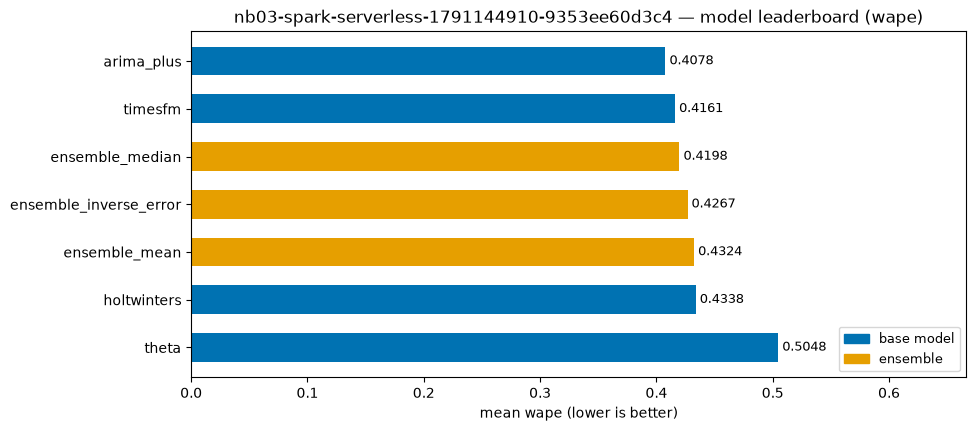

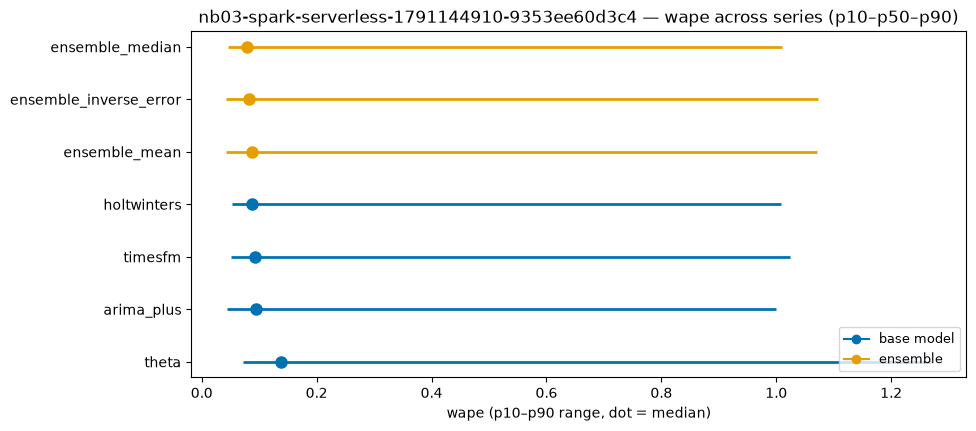

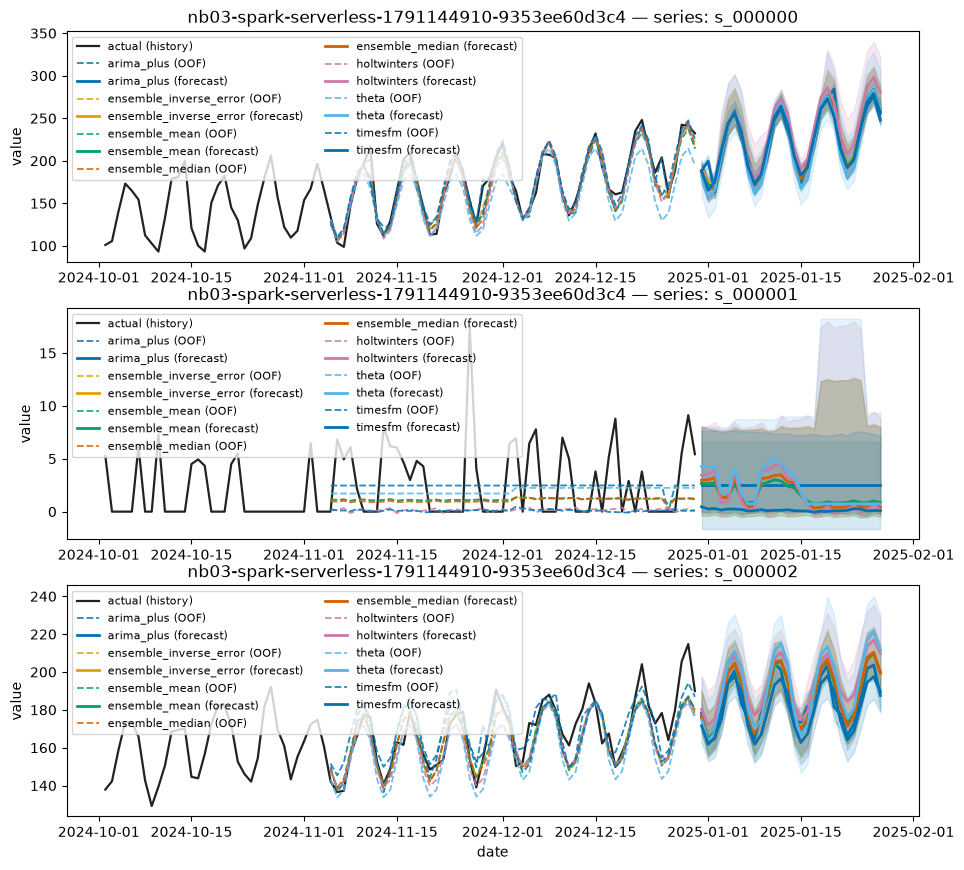

,kind,lane,label,start,end,duration_s,status,runtime,model_type,ts_id
0,job,ensemble,ensemble,2026-10-04 20:41:43.913424+00:00,2026-10-04 20:41:56.769781+00:00,12.856357,COMPLETED,bigquery,None,None
1,job,native,native,2026-10-04 20:15:58.931218+00:00,2026-10-04 20:19:15.380645+00:00,196.449427,COMPLETED,bigquery,None,None
2,job,statistical,statistical,2026-10-04 20:15:59.001650+00:00,2026-10-04 20:41:38.827495+00:00,1539.825845,COMPLETED,spark,None,None
3,cell,gdpic-srvls-batch-2c006b46-c782-4e8a-9407-9b36...,holtwinters:s_000000,2026-10-04 20:39:02.956745+00:00,2026-10-04 20:39:37.351438+00:00,34.394693,None,spark,holtwinters,s_000000
4,cell,gdpic-srvls-batch-2c006b46-c782-4e8a-9407-9b36...,theta:s_000003,2026-10-04 20:39:02.957112+00:00,2026-10-04 20:39:38.083202+00:00,35.126090,None,spark,theta,s_000003
5,cell,gdpic-srvls-batch-2c006b46-c782-4e8a-9407-9b36...,theta:s_000010,2026-10-04 20:39:04.429388+00:00,2026-10-04 20:39:43.051445+00:00,38.622057,None,spark,theta,s_000010
6,cell,gdpic-srvls-batch-2c006b46-c782-4e8a-9407-9b36...,holtwinters:s_000007,2026-10-04 20:39:04.429413+00:00,2026-10-04 20:39:42.681486+00:00,38.252073,None,spark,holtwinters,s_000007
7,cell,gdpic-srvls-batch-2c006b46-c782-4e8a-9407-9b36...,holtwinters:s_000009,2026-10-04 20:39:04.429621+00:00,2026-10-04 20:39:42.573696+00:00,38.144075,None,spark,holtwinters,s_000009
8,cell,gdpic-srvls-batch-2c006b46-c782-4e8a-9407-9b36...,holtwinters:s_000006,2026-10-04 20:39:04.429656+00:00,2026-10-04 20:39:42.658946+00:00,38.229290,None,spark,holtwinters,s_000006
9,cell,gdpic-srvls-batch-2c006b46-c782-4e8a-9407-9b36...,theta:s_000009,2026-10-04 20:39:37.362423+00:00,2026-10-04 20:39:38.124827+00:00,0.762404,None,spark,theta,s_000009


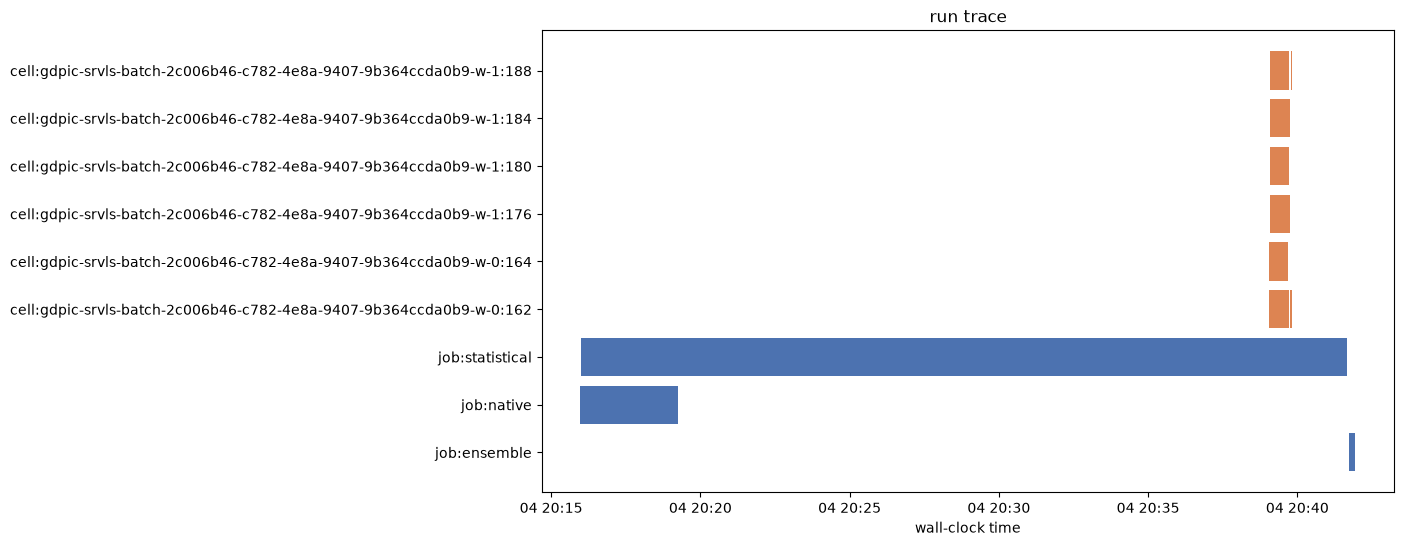

In [5]:
import matplotlib.pyplot as plt
from scale_forecasting import plot_leaderboard, plot_metric_distribution, plot_trace

display(forecaster.leaderboard_df())

review = forecaster.review_run()
plot_leaderboard(review)
plt.show()

plot_metric_distribution(review)
plt.show()

forecaster.plot_forecasts(history_tail=90)
plt.show()

trace_df = forecaster.trace()
display(trace_df)
plot_trace(trace_df)
plt.show()

## Act 5 · Deep Dive: Dataproc Standard Cluster, Spark Connect & Direct UDF Embedding (`spark_io.run_group`)

1. **Dataproc Standard Cluster (`compute.spark_mode = 'cluster'`):** Provisions an ephemeral GCE-backed Dataproc cluster.
2. **Interactive Spark Connect (`DataprocSparkSession`):** Pass a live `spark` session directly to `forecaster.run_live(spark=spark)`.
3. **Direct Engine Embedding (`spark_io.run_group` & `aggregate_status`):** If your team already runs a PySpark ETL pipeline, you can invoke the exact grouped-Pandas UDF body (`run_group`) directly on any bucket DataFrame!

In [6]:
from scale_forecasting.engines.spark_io import aggregate_status, default_bucket_count, fanout_properties, run_group
from scale_forecasting.playground import sample_data

cluster_preview_cfg = cfg.model_copy(
    update={"compute": cfg.compute.model_copy(update={"spark_mode": "cluster"})}
)
display(Forecaster(cluster_preview_cfg, settings=settings).explain(validate_data=False))

# Direct Spark UDF Embedding Demo: run_group() + aggregate_status() on a bucket frame
bucket_df = sample_data(n_series=3, history=180, freq="D")
n_buckets = default_bucket_count(cfg, models=["theta", "holtwinters"], n_series=3)
print("Spark shuffle fanout properties:", fanout_properties(n_buckets))
cells, status_df = run_group(bucket_df, cfg, models=["theta", "holtwinters"])
display(status_df)
print("Aggregated driver outcome:", aggregate_status(status_df))

,run_id,family,job_key,runtime,machine_type,workers,hardware,gpu_type,models,training_modes,n_series,n_folds,expected_cells,covariates,depends_on
0,nb03-spark-serverless-1791144910-9353ee60d3c4,statistical,sf-nb03-spark-serverless-1791144910-9353ee60d3...,spark,None,NaN,cpu,None,"theta, holtwinters","theta:local, holtwinters:local",12,2,24,none,
1,nb03-spark-serverless-1791144910-9353ee60d3c4,native,sf-nb03-spark-serverless-1791144910-9353ee60d3...,bigquery,sql,1.0,sql,None,"arima_plus, timesfm","arima_plus:local, timesfm:local",12,2,24,none,
2,nb03-spark-serverless-1791144910-9353ee60d3c4,ensemble,sf-nb03-spark-serverless-1791144910-9353ee60d3...,bigquery,sql,1.0,sql,None,"ensemble_mean, ensemble_median, ensemble_inver...",barrier,12,2,36,none,sf-nb03-spark-serverless-1791144910-9353ee60d3...


Spark shuffle fanout properties: {'spark.sql.shuffle.partitions': '9', 'spark.sql.adaptive.coalescePartitions.enabled': 'false'}


,ts_id,model_type,status,fit_seconds
0,s_000000,theta,ok,0.584633
1,s_000000,holtwinters,ok,1.090402
2,s_000001,theta,ok,1.070092
3,s_000001,holtwinters,ok,0.764226
4,s_000002,theta,ok,0.286432
5,s_000002,holtwinters,ok,0.780421


Aggregated driver outcome: RunOutcome(n_series=3, n_cells=6, n_ok=6, n_error=0, status='COMPLETED')
